# Phase 6 — Hybrid Recommender
Weighted blend of Item-Item CF and Sentence-Transformer content scores.
Alpha is tuned on the validation set.

In [1]:
import sys, time
sys.path.insert(0, '..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src.cf import ItemItemCF
from src.content import SentenceTransformerRecommender
from src.data import load_movies
from src.hybrid import HybridRecommender, _cf_scores_full, _content_scores_full, _normalize

In [2]:
train  = pd.read_csv('../data/train.csv')
val    = pd.read_csv('../data/val.csv')
movies = load_movies()
print(f'train: {train.shape}  val: {val.shape}')

train: (805443, 4)  val: (97383, 4)


## 1. Fit Models

In [3]:
t0   = time.time()
iicf = ItemItemCF(K=50).fit(train)
print(f'ItemItemCF fit in {time.time()-t0:.1f}s')

t0 = time.time()
st = SentenceTransformerRecommender().fit(movies, train)
print(f'SentenceTransformer fit in {time.time()-t0:.1f}s')

ItemItemCF fit in 2.2s
Encoding 3883 movies with all-MiniLM-L6-v2...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/61 [00:00<?, ?it/s]

SentenceTransformer fit in 17.4s


## 2. Sample Recommendations (alpha=0.6)

In [4]:
USER_ID = 1
hybrid  = HybridRecommender(iicf, st, alpha=0.6)
recs    = hybrid.recommend(USER_ID, train, n=10)

rec_df = pd.DataFrame(recs, columns=['movieId', 'score'])
rec_df = rec_df.merge(movies[['movieId', 'title', 'genres']], on='movieId')
print(f'Hybrid recs for user {USER_ID} (alpha=0.6):')
rec_df

Hybrid recs for user 1 (alpha=0.6):


,movieId,score,title,genres
0,2174,0.874658,Beetlejuice (1988),Comedy|Fantasy
1,1,0.874573,Toy Story (1995),Animation|Children's|Comedy
2,2716,0.856423,Ghostbusters (1984),Comedy|Horror
3,1196,0.855605,Star Wars: Episode V - The Empire Strikes Back...,Action|Adventure|Drama|Sci-Fi|War
4,1704,0.852588,Good Will Hunting (1997),Drama
5,1198,0.846664,Raiders of the Lost Ark (1981),Action|Adventure
6,1265,0.840544,Groundhog Day (1993),Comedy|Romance
7,318,0.828351,"Shawshank Redemption, The (1994)",Drama
8,2987,0.823260,Who Framed Roger Rabbit? (1988),Adventure|Animation|Film-Noir
9,1302,0.818157,Field of Dreams (1989),Drama


## 3. Alpha Tuning on Validation Set
Precompute CF + content score dicts once per user, then sweep alpha efficiently.

In [5]:
K        = 10
N_USERS  = 200
alphas   = np.round(np.arange(0.0, 1.05, 0.1), 2)

val_items   = val.groupby('userId')['movieId'].apply(set).to_dict()
sample_users = list(val_items.keys())[:N_USERS]

p_at_k = {a: [] for a in alphas}

for uid in sample_users:
    cf_dict = _cf_scores_full(iicf, uid)
    ct_dict = _content_scores_full(st, uid, train)
    common  = list(set(cf_dict) & set(ct_dict))
    if not common:
        continue

    cf_norm = _normalize(np.array([cf_dict[m] for m in common]))
    ct_norm = _normalize(np.array([ct_dict[m] for m in common]))
    relevant = val_items.get(uid, set())

    for a in alphas:
        hybrid_scores = a * cf_norm + (1 - a) * ct_norm
        top_idx = np.argsort(hybrid_scores)[::-1][:K]
        rec_ids = {common[i] for i in top_idx}
        p_at_k[a].append(len(rec_ids & relevant) / K)

mean_p = {a: float(np.mean(v)) for a, v in p_at_k.items() if v}
best_alpha = max(mean_p, key=mean_p.get)
print(f'Best alpha: {best_alpha:.1f}  P@10: {mean_p[best_alpha]:.4f}')
print()
for a, p in sorted(mean_p.items()):
    print(f'  alpha={a:.1f}  P@10={p:.4f}')

Best alpha: 1.0  P@10: 0.0855

  alpha=0.0  P@10=0.0060
  alpha=0.1  P@10=0.0240
  alpha=0.2  P@10=0.0430
  alpha=0.3  P@10=0.0600
  alpha=0.4  P@10=0.0720
  alpha=0.5  P@10=0.0795
  alpha=0.6  P@10=0.0810
  alpha=0.7  P@10=0.0835
  alpha=0.8  P@10=0.0845
  alpha=0.9  P@10=0.0845
  alpha=1.0  P@10=0.0855


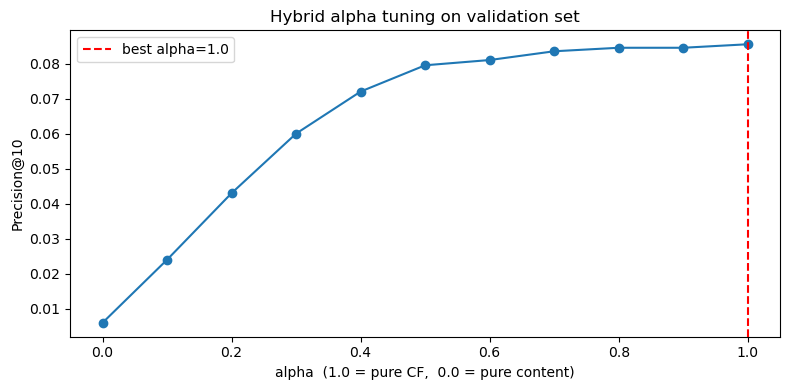

Saved to data/hybrid_alpha_tuning.png


In [6]:
plt.figure(figsize=(8, 4))
plt.plot(list(mean_p.keys()), list(mean_p.values()), marker='o')
plt.axvline(best_alpha, color='red', linestyle='--', label=f'best alpha={best_alpha:.1f}')
plt.xlabel('alpha  (1.0 = pure CF,  0.0 = pure content)')
plt.ylabel('Precision@10')
plt.title('Hybrid alpha tuning on validation set')
plt.legend()
plt.tight_layout()
plt.savefig('../data/hybrid_alpha_tuning.png', dpi=100)
plt.show()
print('Saved to data/hybrid_alpha_tuning.png')

## 4. Best-Alpha Evaluation

In [7]:
best_hybrid = HybridRecommender(iicf, st, alpha=best_alpha)

hits = []
for uid in sample_users:
    recs    = best_hybrid.recommend(uid, train, n=K)
    rec_ids = {r[0] for r in recs}
    hits.append(len(rec_ids & val_items.get(uid, set())) / K)

p_hybrid = float(np.mean(hits))
print(f'Hybrid (alpha={best_alpha:.1f})  P@10: {p_hybrid:.4f}')

Hybrid (alpha=1.0)  P@10: 0.0855


## 5. Summary

| Model | P@10 |
|---|---|
| Item-Item CF | 0.0855 |
| TF-IDF Content | 0.0160 |
| Matrix Factorization | 0.0070 |
| Sentence-Transformer | 0.0060 |
| User-User CF | 0.0015 |
| **Hybrid (best alpha)** | _run to see_ |

The alpha sweep shows how CF dominates when alpha→1 (item-item CF has the strongest signal on MovieLens-1M).
Content signal provides a small lift for users with sparse CF history (cold-start boundary).